## [pyKNEEr](https://github.com/sbonaretti/pyKNEEr)

# [Segmentation quality](https://sbonaretti.github.io/pyKNEEr/segmentation.html)
Content under Creative Commons Attribution license CC-BY-NC-SA 4.0   
Code under GNU-GPL v3 License  
© 2019 Serena Bonaretti
---

Segmentation quality is evaluated using 3 measures of *overlap agreement* [1]:  
- Dice coefficient  
- Jaccard coefficient 
- Volume similarity  

and 1 measure of *surface distance*:
- Average Euclidean distance

---

## Import packages

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pykneer import pykneer_io                  as io
from pykneer import segmentation_quality_for_nb as sq

## Image information

Input and output:   
- `input_file_name` contains the list of the masks segmented using pyKNEEr and of ground truth masks
- `output_file_name` contains the table of the overlap coefficients

In [3]:
# input_file_name  = "./image_list_segmentation_quality_OAI1_DESS.txt" # commented out because downloaded from GitHub
input_file_name            = "segmentation_quality.txt"
output_file_name_overlap   = "output_file_overlap_here.csv"
output_file_name_distances = "output_file_distance_here.csv"

#### Reading image data
- `image_data` is a dictionary (or struct), where each cell corresponds to an image. For each image, information such as paths and file names are stored  

In [4]:
image_data = io.load_image_data_segmentation_quality(input_file_name)

-> image information loaded


---

## Calculating overlap coefficients

In [5]:
dice_coeff, jacc_coeff, vol_simil = sq.compute_overlap(image_data)

## Visualizing overlap coefficients

The values of overlap coefficient are visualized as:
- a GRAPH, to visually observe the trend of the dataset 
- a TABLE, to observe the numerical values

#### GRAPH: Dots represent the coefficient value

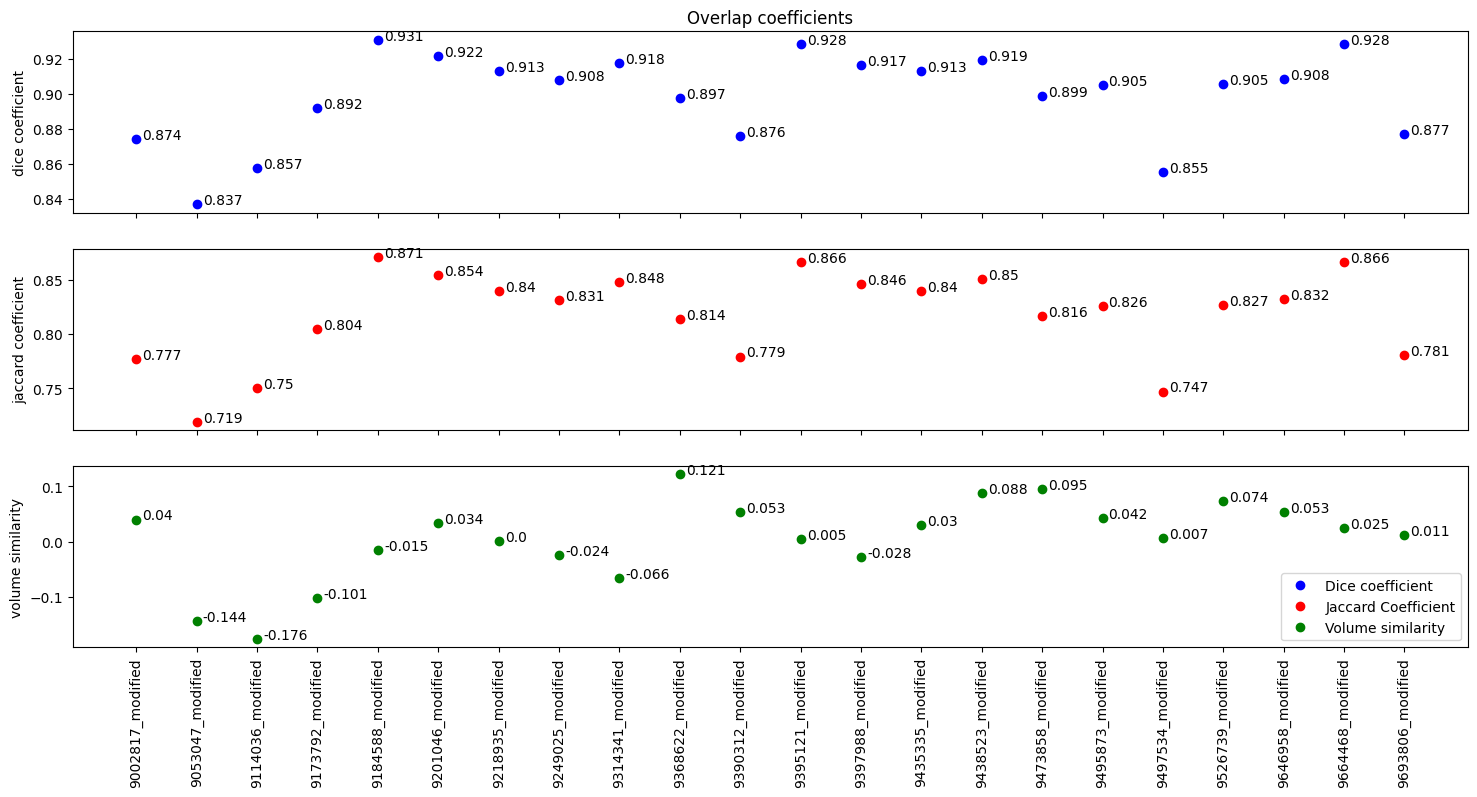

In [6]:
sq.overlap_coeff_graph(image_data, dice_coeff, jacc_coeff, vol_simil)

#### TABLE: Overlap coefficients per image
The table is saved as a .csv file for subsequent analyisis

In [7]:
coeff = sq.overlap_coeff_table(image_data, dice_coeff, jacc_coeff, vol_simil, output_file_name_overlap)
display(coeff)

Table saved as: output_file_overlap_here.csv


,subjects,dice_coeff,jaccard_coeff,volume_similarity
1,9002817_modified,0.87,0.78,0.04
2,9053047_modified,0.84,0.72,-0.14
3,9114036_modified,0.86,0.75,-0.18
4,9173792_modified,0.89,0.80,-0.10
5,9184588_modified,0.93,0.87,-0.01
6,9201046_modified,0.92,0.85,0.03
7,9218935_modified,0.91,0.84,0.00
8,9249025_modified,0.91,0.83,-0.02
9,9314341_modified,0.92,0.85,-0.07
10,9368622_modified,0.90,0.81,0.12


---

## Calculating surface distances

In [8]:
mean_distances, stddev_distances = sq.compute_surface_distance(image_data)

## Visualizing surface distances

The values of surface distances are visualized as:
- a GRAPH, to visually observe the trend of the dataset 
- a TABLE, to observe the numerical values

#### GRAPH: Dots represent the mean surface distance

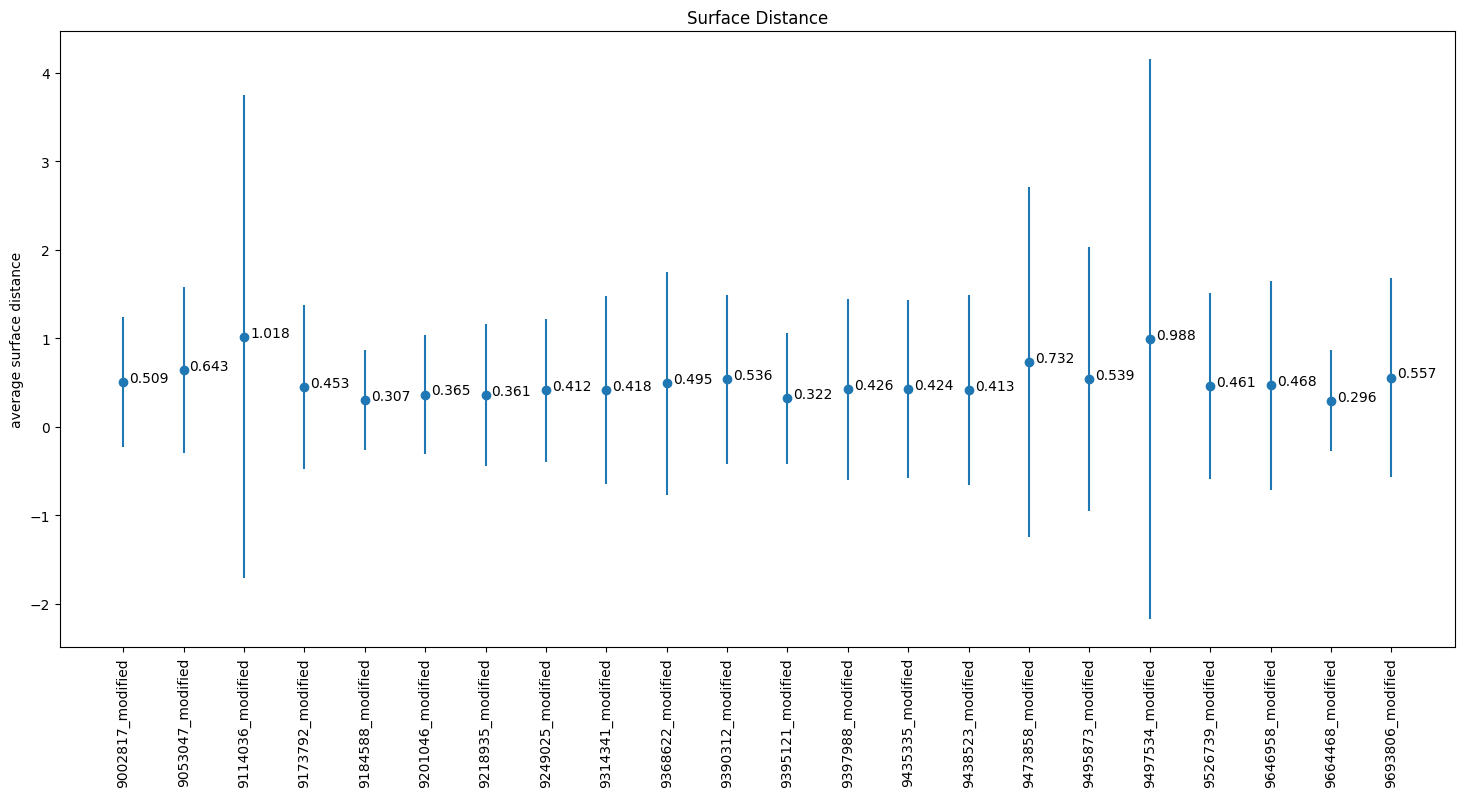

In [9]:
sq.surface_distance_graph(image_data, mean_distances, stddev_distances)

#### TABLE: Average distances per image
The table is saved as a .csv file for subsequent analyisis

In [10]:
table = sq.surface_distance_table(image_data, mean_distances, stddev_distances, output_file_name_distances)
display(table)

Table saved as: output_file_distance_here.csv


,subjects,mean_distances,stddev_distances
1,9002817_modified,0.51,0.74
2,9053047_modified,0.64,0.94
3,9114036_modified,1.02,2.73
4,9173792_modified,0.45,0.92
5,9184588_modified,0.31,0.57
6,9201046_modified,0.36,0.68
7,9218935_modified,0.36,0.80
8,9249025_modified,0.41,0.81
9,9314341_modified,0.42,1.06
10,9368622_modified,0.49,1.26


---

### References

[1] Tustison N.J., Gee J.C. [*Introducing Dice, Jaccard, and Other Label Overlap Measures To ITK*](http://insight-journal.org/browse/publication/707) The Insight Journal. July-December. 2009.

### Dependencies

In [11]:
%load_ext watermark
%watermark -v -m -p pykneer,SimpleITK,matplotlib,numpy,pandas
print (" ")
%watermark -u -n -t -z

Python implementation: CPython
Python version       : 3.12.2
IPython version      : 8.26.0

pykneer   : unknown
SimpleITK : 2.4.1
matplotlib: 3.10.1
numpy     : 1.26.4
pandas    : 2.2.3

Compiler    : GCC 12.3.0
OS          : Linux
Release     : 6.8.0-39-generic
Machine     : x86_64
Processor   : x86_64
CPU cores   : 32
Architecture: 64bit

 
Last updated: Sun Sep 07 2025 15:50:31IST

